In [76]:
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import date, timedelta
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from category_encoders import OneHotEncoder

In [43]:
ticker = ["MSUMI.NS"]
day_msumi = yf.download(ticker, period="max")


C:\Users\VICTUS\AppData\Local\Temp\ipykernel_23532\928882182.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  day_msumi = yf.download(ticker, period="max")
[*********************100%***********************]  1 of 1 completed


In [45]:
day_msumi.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 925 entries, 2022-03-28 to 2025-12-19
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   (Close, MSUMI.NS)   925 non-null    float64
 1   (High, MSUMI.NS)    925 non-null    float64
 2   (Low, MSUMI.NS)     925 non-null    float64
 3   (Open, MSUMI.NS)    925 non-null    float64
 4   (Volume, MSUMI.NS)  925 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 43.4 KB


In [46]:
day_msumi

Price,Close,High,Low,Open,Volume
Ticker,MSUMI.NS,MSUMI.NS,MSUMI.NS,MSUMI.NS,MSUMI.NS
Date,,,,,
2022-03-28,28.103357,31.052055,28.103357,29.577706,42214051
2022-03-29,26.719738,27.218748,26.719738,26.719738,107432712
2022-03-30,27.967260,28.035309,25.404162,25.404162,114514962
2022-03-31,29.237469,29.350880,26.901193,27.445568,20994001
2022-04-01,29.373564,30.689139,27.785804,28.965282,86487987
...,...,...,...,...,...
2025-12-15,45.970001,46.490002,45.639999,45.910000,2394942
2025-12-16,45.509998,46.599998,45.270000,46.200001,5585698


In [47]:
hourly_msumi =yf.download(ticker, period="730d", interval="1h")
# msumi_hourly =data.history(period = "730d", interval = "1h")

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_23532\709566807.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  hourly_msumi =yf.download(ticker, period="730d", interval="1h")
[*********************100%***********************]  1 of 1 completed


In [59]:
hourly_msumi

Price,Close,High,Low,Open,Volume
Ticker,MSUMI.NS,MSUMI.NS,MSUMI.NS,MSUMI.NS,MSUMI.NS
Datetime,,,,,
2023-01-06 03:45:00+00:00,37.433334,38.000000,37.399998,37.866665,0
2023-01-06 04:45:00+00:00,37.466667,37.600002,37.399998,37.399998,89408
2023-01-06 05:45:00+00:00,37.533333,37.566666,37.466667,37.466667,67124
2023-01-06 06:45:00+00:00,36.866665,37.566666,36.566666,37.533333,741148
2023-01-06 07:45:00+00:00,36.700001,36.933334,36.600002,36.933334,446515
...,...,...,...,...,...
2025-12-19 05:45:00+00:00,46.000000,46.000000,45.750000,45.900002,479449
2025-12-19 06:45:00+00:00,46.349998,46.349998,45.930000,46.000000,876074


In [49]:
hourly_msumi.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5078 entries, 2023-01-06 03:45:00+00:00 to 2025-12-19 09:45:00+00:00
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   (Close, MSUMI.NS)   5078 non-null   float64
 1   (High, MSUMI.NS)    5078 non-null   float64
 2   (Low, MSUMI.NS)     5078 non-null   float64
 3   (Open, MSUMI.NS)    5078 non-null   float64
 4   (Volume, MSUMI.NS)  5078 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 238.0 KB


In [67]:
# Deleting the extra row header
hrs_msumi= hourly_msumi.droplevel((1), axis=1)
hrs_msumi = hrs_msumi.reset_index()

# hrs_msumi.set_index('Datetime', inplace=True)
hrs_msumi


Price,Datetime,Close,High,Low,Open,Volume
0,2023-01-06 03:45:00+00:00,37.433334,38.000000,37.399998,37.866665,0
1,2023-01-06 04:45:00+00:00,37.466667,37.600002,37.399998,37.399998,89408
2,2023-01-06 05:45:00+00:00,37.533333,37.566666,37.466667,37.466667,67124
3,2023-01-06 06:45:00+00:00,36.866665,37.566666,36.566666,37.533333,741148
4,2023-01-06 07:45:00+00:00,36.700001,36.933334,36.600002,36.933334,446515
...,...,...,...,...,...,...
5073,2025-12-19 05:45:00+00:00,46.000000,46.000000,45.750000,45.900002,479449
5074,2025-12-19 06:45:00+00:00,46.349998,46.349998,45.930000,46.000000,876074
5075,2025-12-19 07:45:00+00:00,47.349998,47.349998,46.310001,46.349998,2132995
5076,2025-12-19 08:45:00+00:00,47.770000,49.590000,47.320000,47.340000,35829594


<Axes: >

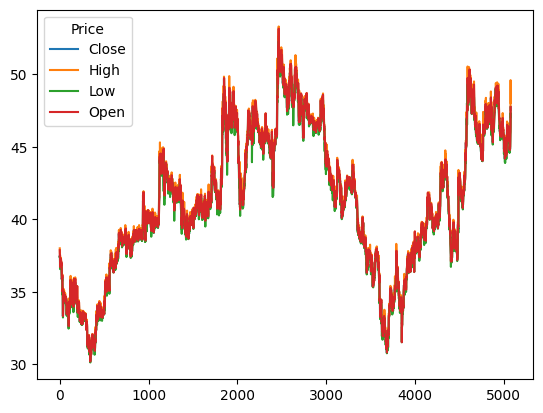

In [75]:
hrs_msumi.describe()
hrs_msumi["Close"].median()
hrs_msumi[["Close", "High", "Low", "Open"]].plot()

In [77]:
target = hrs_msumi["Close"]
x = hrs_msumi.drop(columns=target)
y= hrs_msumi[target]

print("x shape is : ", x.shape)
print("x shape is : ", x.shape)

KeyError: '[37.43333435058594, 37.46666717529297, 37.53333282470703, 36.86666488647461, 36.70000076293945, 36.70000076293945, 36.733333587646484, 37.266666412353516, 37.20000076293945, 37.266666412353516, 36.766666412353516, 36.83333206176758, 37.10000228881836, 37.06666564941406, 37.13333511352539, 36.96666717529297, 37.0, 36.96666717529297, 37.0, 36.79999923706055, 36.66666793823242, 36.36666488647461, 36.20000076293945, 35.86666488647461, 35.96666717529297, 35.96666717529297, 35.96666717529297, 35.89999771118164, 36.13333511352539, 35.233333587646484, 35.03333282470703, 35.0, 35.06666564941406, 35.06666564941406, 35.0, 33.33333206176758, 33.46666717529297, 34.10000228881836, 34.233333587646484, 34.93333435058594, 34.66666793823242, 34.63333511352539, 34.79999923706055, 35.10000228881836, 35.0, 35.03333282470703, 34.66666793823242, 34.79999923706055, 34.766666412353516, 34.83333206176758, 34.63333511352539, 34.63333511352539, 34.66666793823242, 34.56666564941406, 34.66666793823242, 3